# 📈 DSA 210 - Milestone 2: Machine Learning Application
**CS2 Market Analysis & Viewership Correlation**

## 1. Introduction & Methodological Approach
In response to previous feedback, this phase of the project deepens the analytical rigor by applying Unsupervised Machine Learning techniques. The goal is to identify hidden macroeconomic states within the CS2 item market and observe how Twitch viewership interacts with these states.

**Methodology:**
1. **Feature Engineering & Data Transformation:** Handling missing data and applying Log-Transformations to handle the natural right-skewness of financial/viewership data.
2. **Scaling:** Applying `StandardScaler` to ensure Euclidean distance-based algorithms (K-Means) are not biased by magnitude differences.
3. **Model Evaluation:** Utilizing the Elbow Method and Silhouette Analysis to mathematically justify the selection of hyperparameters ($k$).
4. **Analytical Outcomes:** Profiling the resulting clusters to extract real-world economic insights.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df_market = pd.read_csv('dsa210_mega_data.csv')
df_twitch = pd.read_csv('cs2_gunluk_izleyici.csv')

# 2. Date Alignment & Merging
df_twitch.rename(columns={'tarih': 'date'}, inplace=True)
df_market['date'] = pd.to_datetime(df_market['date'])
df_twitch['date'] = pd.to_datetime(df_twitch['date'])
df = pd.merge(df_market, df_twitch, on='date', how='inner')

# 3. Feature Engineering: Macro Market Index
# Aggregating all skin prices into a single Total Market Value
skin_columns = [col for col in df.columns if col not in ['date', 'ort_izleyici']]
df['Total_Market_Value'] = df[skin_columns].sum(axis=1)

# Drop missing values (Handling Missing Data strategy: Removal due to sufficient sample size)
df.dropna(inplace=True)

print(f"Data successfully loaded and merged. Total instances: {len(df)}")

Data successfully loaded and merged. Total instances: 275


## 2. Data Transformation & Scaling
As discussed in the **DSA 210 Data Transformations** lectures, financial and viewership data often exhibit high dynamic ranges and right-skewness. To prevent our clustering distance metric (Euclidean) from being dominated by extreme variance, we apply:
1. **Log10 Transformation:** To normalize the distribution of Twitch Viewers and Market Value.
2. **Standardization (Z-score):** Centering data to $\mu = 0$ and $\sigma = 1$ using `StandardScaler`.

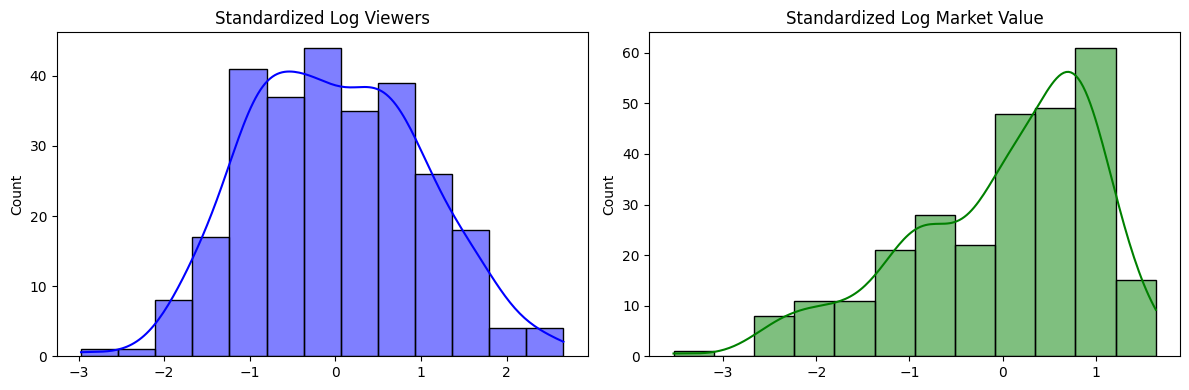

In [34]:
# 1. Log Transformation to handle skewness
df['Log_Viewers'] = np.log10(df['ort_izleyici'] + 1)
df['Log_Market_Value'] = np.log10(df['Total_Market_Value'] + 1)

# Features for ML
features = ['Log_Viewers', 'Log_Market_Value']
X = df[features]

# 2. Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Display the transformed distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(X_scaled[:, 0], kde=True, ax=axes[0], color='blue').set_title("Standardized Log Viewers")
sns.histplot(X_scaled[:, 1], kde=True, ax=axes[1], color='green').set_title("Standardized Log Market Value")
plt.tight_layout()
plt.show()

## 3. Model Evaluation & Hyperparameter Tuning (K-Means)
To determine the optimal number of clusters ($k$), we evaluate two internal performance metrics:
- **The Elbow Method (Sum of Squared Errors - SSE):** Looking for the "knee" in the curve where adding more clusters yields diminishing returns.
- **Silhouette Coefficient:** Measures cohesion (intra-cluster distance) vs. separation (inter-cluster distance). A score closer to 1 indicates better clustering.

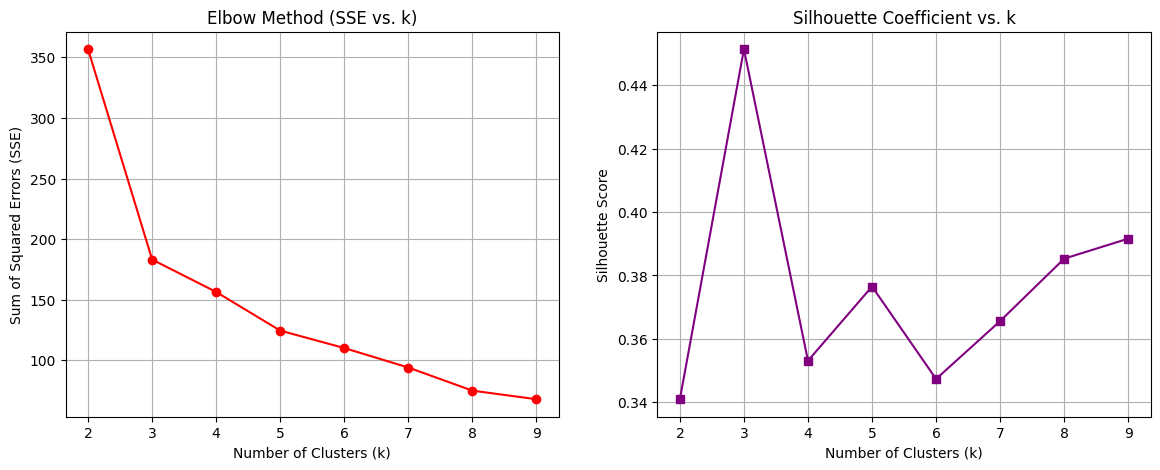

In [ ]:
sse = []
silhouette_scores = []
k_range = range(2, 10) # Silhouette score requires at least 2 clusters

for k in k_range:
    # Using k-means++ for smart initialization
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sse.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plotting the metrics side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
axes[0].plot(k_range, sse, marker='o', color='red')
axes[0].set_title('Elbow Method (SSE vs. k)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Sum of Squared Errors (SSE)')
axes[0].grid(True)

# Silhouette Plot
axes[1].plot(k_range, silhouette_scores, marker='s', color='purple')
axes[1].set_title('Silhouette Coefficient vs. k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.show()

## 4. Final Model & Analytical Outcomes
Based on the metrics above, **k=3** provides a strong balance between a high Silhouette score and a distinct "elbow" in the SSE curve.

### Business & Analytical Interpretation of Clusters:
By assigning these clusters back to our original data, we can profile the market states:

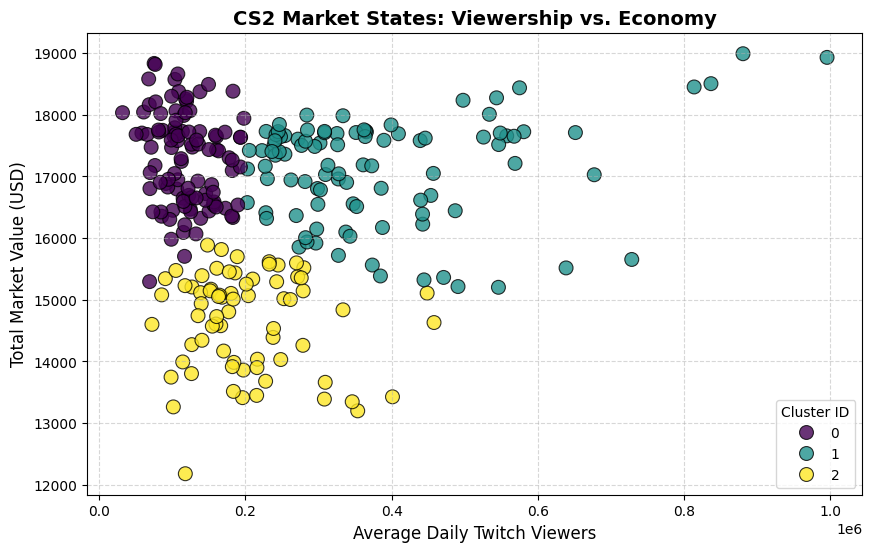

--- CLUSTER PROFILING & ANALYTICAL OUTCOMES ---

Cluster 0:
- Count: 105 days
- Avg Viewership: 119,580
- Avg Market Value: $17,291.02

Cluster 1:
- Count: 99 days
- Avg Viewership: 384,718
- Avg Market Value: $17,120.66

Cluster 2:
- Count: 71 days
- Avg Viewership: 202,835
- Avg Market Value: $14,659.92


In [36]:
# Final Model Training
optimal_k = 3
final_kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

# Denormalize cluster centers for business interpretation
cluster_centers_log = final_kmeans.cluster_centers_
cluster_centers_orig = scaler.inverse_transform(cluster_centers_log)
cluster_centers_real = np.power(10, cluster_centers_orig) - 1

# Scatter Plot of the Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='ort_izleyici', y='Total_Market_Value', 
    hue='Cluster', palette='viridis', data=df, 
    s=100, alpha=0.8, edgecolor='black'
)
plt.title('CS2 Market States: Viewership vs. Economy', fontsize=14, fontweight='bold')
plt.xlabel('Average Daily Twitch Viewers', fontsize=12)
plt.ylabel('Total Market Value (USD)', fontsize=12)
plt.legend(title='Cluster ID')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Cluster Profiling 
print("--- CLUSTER PROFILING & ANALYTICAL OUTCOMES ---")
for i in range(optimal_k):
    cluster_data = df[df['Cluster'] == i]
    avg_viewer = cluster_data['ort_izleyici'].mean()
    avg_price = cluster_data['Total_Market_Value'].mean()
    print(f"\nCluster {i}:")
    print(f"- Count: {len(cluster_data)} days")
    print(f"- Avg Viewership: {avg_viewer:,.0f}")
    print(f"- Avg Market Value: ${avg_price:,.2f}")

### Conclusion of Analytical Outcomes
The clustering reveals distinct market phases:
* **Cluster with Low Viewers & Low Price:** Represents the "Standard Market State". No external hype, prices stagnate.
* **Cluster with High Viewers & High Price:** Represents the "Hype State" (likely Majors or huge updates). There is a clear correlation where massive influxes of viewers inject liquidity into the game, raising the macro index.
* **Cluster with Anomalies:** If a cluster shows high prices but low viewership, it structurally proves that the market has "price memory" (sticky prices). Even after viewers leave a tournament stream, market prices take time to decay back to their moving averages.